In [1]:
import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


Code Directory: /home/arash/HVD_SDF
Test Step files Directory: /home/arash/HVD_SDF/Testparts
device: cuda
PyVista backend: trame



=== Active Face Info ===
XYZ bounds:
  X: [-0.000000, 10.000000]  span=10.000000
  Y: [-0.127468, 2.100919]  span=2.228387
  Z: [-2.032622, 1.938721]  span=3.971343

UV bounds:
  U: [-0.039832, 3.264132]
  V: [-5.000000, 5.000000]

Periodic:
  U periodic: False
  V periodic: False



Widget(value='<iframe src="http://localhost:44603/index.html?ui=P_0x73fde83d4040_0&reconnect=auto" class="pyvi…

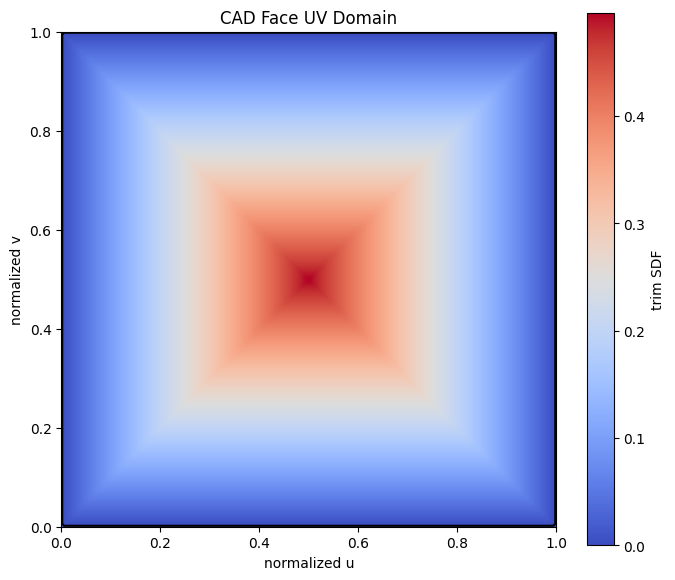

In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = CircularSurf1

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=128,
)
domain = Face_Cad.generate_from_file(shape_path)
Face_Cad.print_face_info()
viz = CADDomainVisualizer(Face_Cad)
viz.plot_uv_domain()
viz.show_3d(res_u=200, res_v=200, show_edges=True)


In [3]:
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)

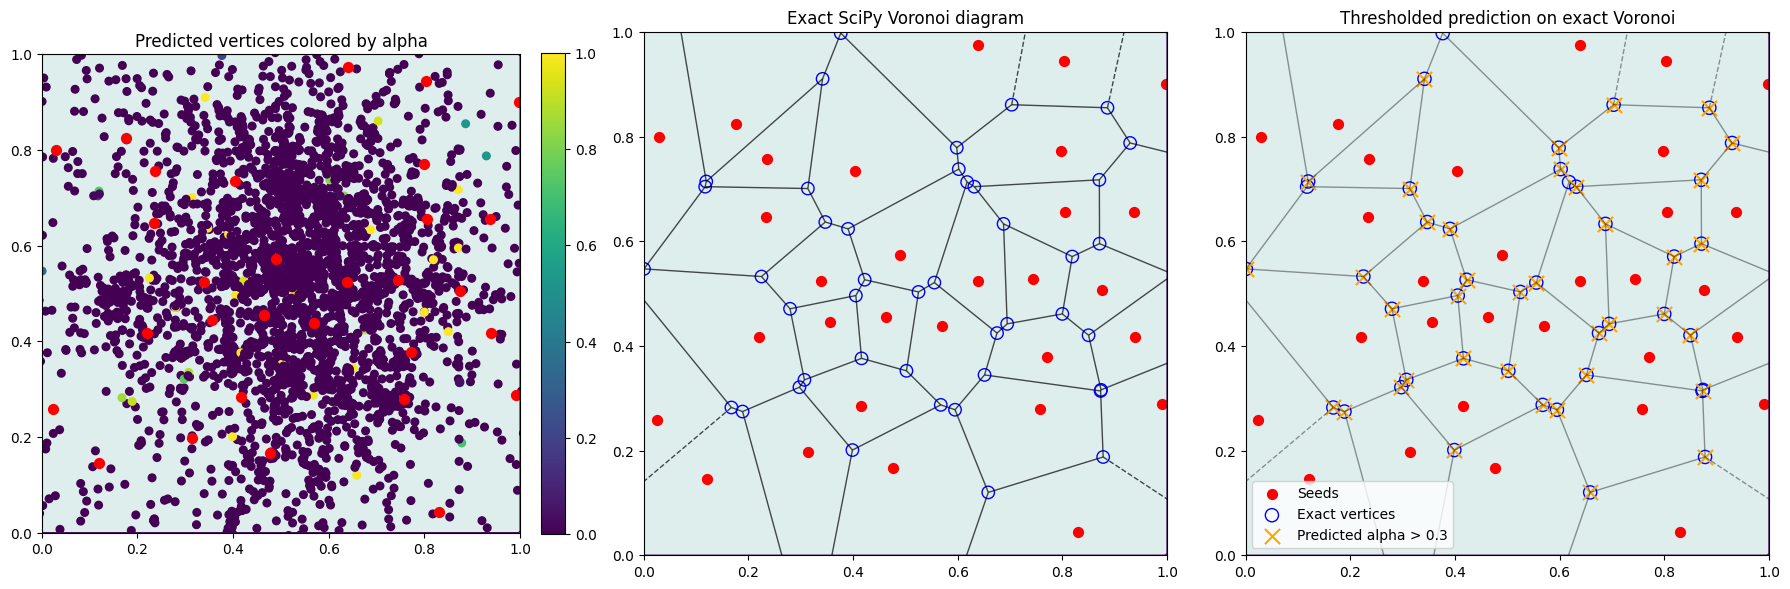

Predicted active vertices: 39
Exact inside vertices: 43
Pred -> exact mean: 5.5461491147848394e-05
Pred -> exact max : 0.0013657187115384288
Exact -> pred mean: 0.0029044386562731717
Exact -> pred max : 0.09413991984913836

Missing exact vertices:
miss_tol = 0.02

--------------------------------
Exact vertex 10
exact uv        = (0.376609, 0.997447)
nearest pred d  = 0.094140
nearest raw idx = 625
nearest raw uv  = (0.376610, 0.997443)
raw distance    = 0.000004
raw alpha       = 2.089666e-01
triple_idx      = [1, 11, 24]
gate         seed = 9.290528e-01
gate        close = 1.000000e+00
gate         area = 1.000000e+00
gate          box = 5.635858e-01
gate         trim = 5.635861e-01
gate empty_circle = 8.715404e-01
gate         keff = 7.418240e-01
vertex_keff     = 3.772843
All predicted Vertices Number = 4060
Thresholded (0.3) predicted vertices = 39, 
alpha min =0.0, alpha max = 0.9999997019767761, alpha mean = 0.008794214576482773


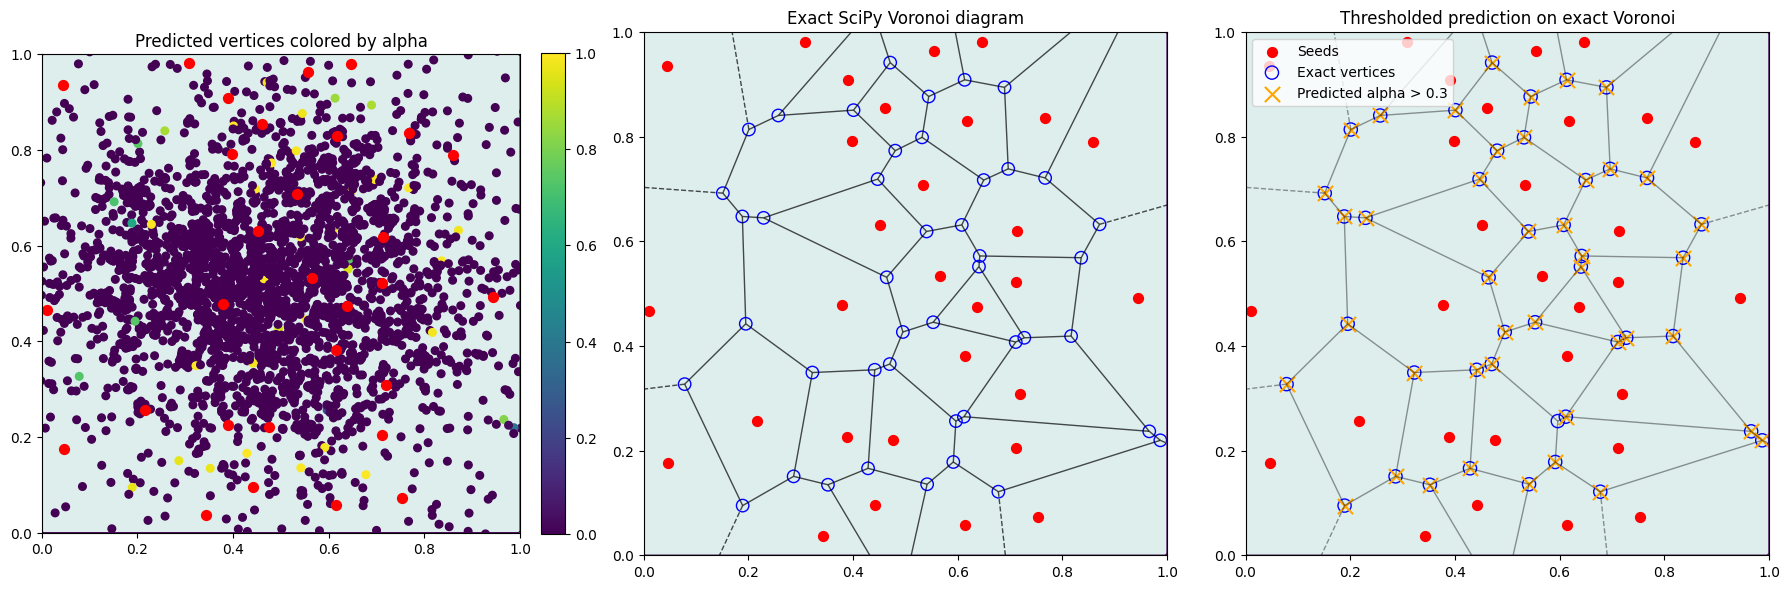

Predicted active vertices: 43
Exact inside vertices: 44
Pred -> exact mean: 2.0406744253817915e-05
Pred -> exact max : 8.042875991827303e-05
Exact -> pred mean: 0.0004134997521403259
Exact -> pred max : 0.01731649909126017

No missing exact vertices with miss_tol=0.02.
All predicted Vertices Number = 4060
Thresholded (0.3) predicted vertices = 43, 
alpha min =0.0, alpha max = 0.9998615980148315, alpha mean = 0.009719481691718102


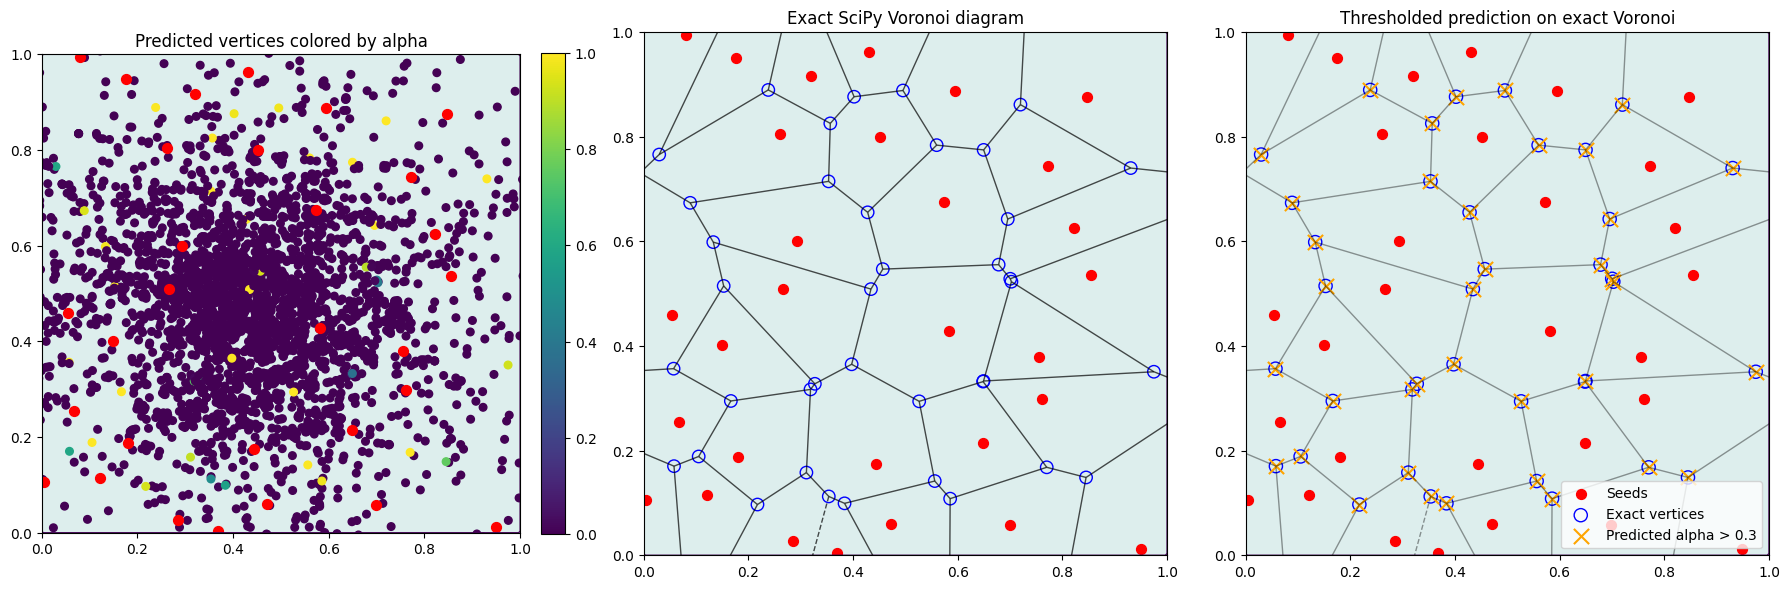

Predicted active vertices: 38
Exact inside vertices: 39
Pred -> exact mean: 1.5136323917145123e-05
Pred -> exact max : 9.029983846260124e-05
Exact -> pred mean: 4.926172158396653e-05
Exact -> pred max : 0.00134602683292318

No missing exact vertices with miss_tol=0.02.
All predicted Vertices Number = 4060
Thresholded (0.3) predicted vertices = 38, 
alpha min =0.0, alpha max = 0.9999690651893616, alpha mean = 0.00826692022383213


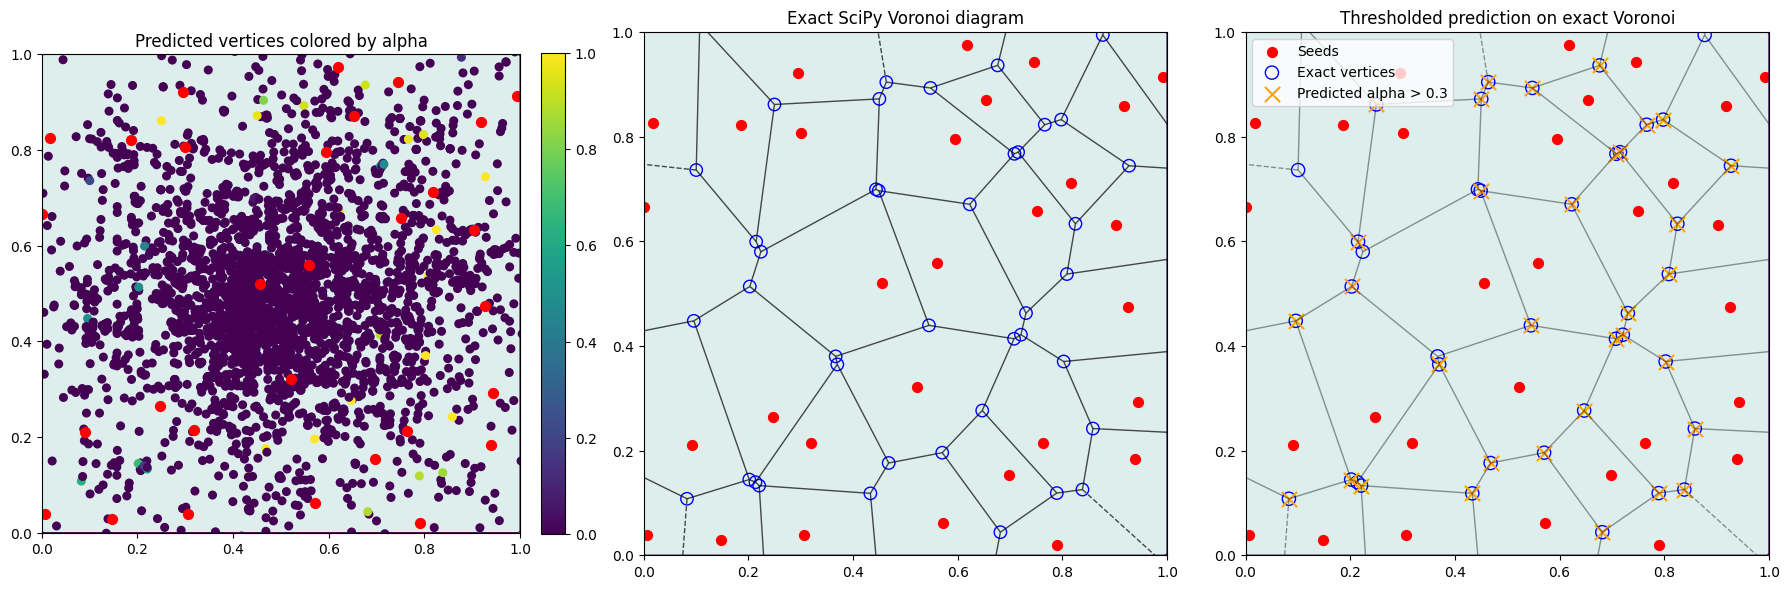

Predicted active vertices: 34
Exact inside vertices: 40
Pred -> exact mean: 1.8027633746079834e-05
Pred -> exact max : 7.604008213197015e-05
Exact -> pred mean: 0.0102882703742135
Exact -> pred max : 0.18009841021765385

Missing exact vertices:
miss_tol = 0.02

--------------------------------
Exact vertex 1
exact uv        = (0.224013, 0.579841)
nearest pred d  = 0.021269
nearest raw idx = 3574
nearest raw uv  = (0.224013, 0.579840)
raw distance    = 0.000002
raw alpha       = 3.172603e-02
triple_idx      = [14, 21, 27]
gate         seed = 5.219620e-01
gate        close = 1.000000e+00
gate         area = 1.000000e+00
gate          box = 1.000000e+00
gate         trim = 1.000000e+00
gate empty_circle = 7.395586e-01
gate         keff = 5.689405e-01
vertex_keff     = 4.062054

--------------------------------
Exact vertex 6
exact uv        = (0.100460, 0.735927)
nearest pred d  = 0.178431
nearest raw idx = 3905
nearest raw uv  = (0.100466, 0.735912)
raw distance    = 0.000016
raw alpha  

In [4]:
dec = ContinuousVoronoiDecoder(
    return_xyz=False,
    min_area=1e-3,
    tau_area=1e-4,
    min_seed_dist=0.01,
    tau_close=0.001,
)

for i in range(1, 5):
    N = 30
    torch.manual_seed(i)
    seeds = random_seeds_min_dist(
        N=N,
        min_dist=0.08,
        seed=i,
        device="cpu",
    )
    # seeds = torch.tensor([
    #     [0.08, 0.10],
    #     [0.28, 0.08],
    #     [0.52, 0.10],
    #     [0.74, 0.08],
    #     [0.92, 0.14],

    #     [0.12, 0.30],
    #     [0.36, 0.26],
    #     [0.60, 0.28],
    #     [0.84, 0.32],

    #     [0.06, 0.52],
    #     [0.26, 0.48],
    #     [0.50, 0.50],
    #     [0.74, 0.48],
    #     [0.94, 0.54],

    #     [0.14, 0.72],
    #     [0.38, 0.70],
    #     [0.62, 0.74],
    #     [0.86, 0.72],

    #     [0.24, 0.92],
    #     [0.76, 0.90],
    # ], dtype=torch.float32)

    out = dec(
        seeds,
        cad_domain=Face_Cad,   # optional; remove if testing only UV
        u_periodic=domain["u_periodic"],
        v_periodic=domain["v_periodic"],
        return_xyz=False,
    )

    vertices = out["vertices_uv"].detach()
    alpha = out["alpha"].detach()
    thr = 0.3
    dec.plot_voronoi_debug(seeds,out,Face_Cad,thr,300)
    print(f"All predicted Vertices Number = {vertices.shape[0]}")
    print(f"Thresholded ({thr}) predicted vertices = {vertices[alpha > thr].shape[0]}, ")
    print(f"alpha min ={alpha.min()}, alpha max = {alpha.max()}, alpha mean = {alpha.mean()}")
